In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('bbc_news_dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None


In [3]:
df.shape

(1490, 3)

In [4]:
df.head(5)

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [5]:
X=df['Text']
y=df['Category']

In [6]:
category_names=df['Category'].unique()
print(category_names)
value_counts=df['Category'].value_counts()
print(value_counts)

['business' 'tech' 'politics' 'sport' 'entertainment']
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


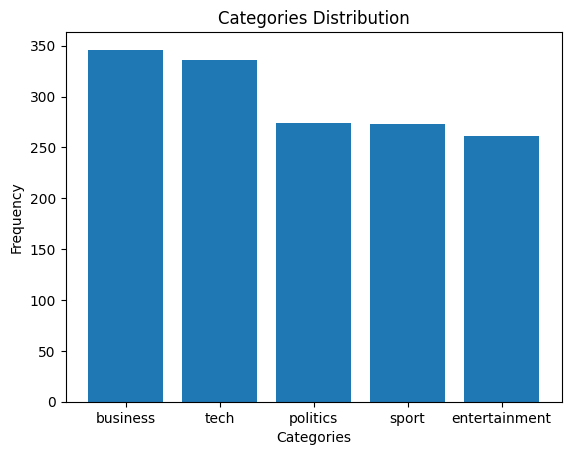

In [7]:
plt.bar(category_names, value_counts)
plt.title("Categories Distribution")
plt.xlabel("Categories")
plt.ylabel("Frequency")
plt.show()

In [8]:
from wordcloud import WordCloud

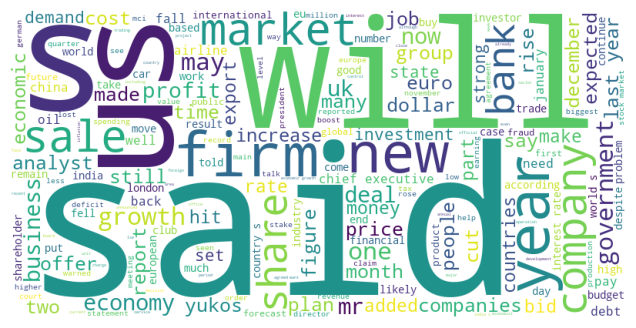

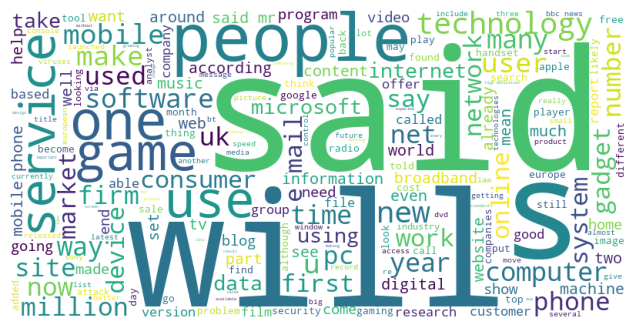

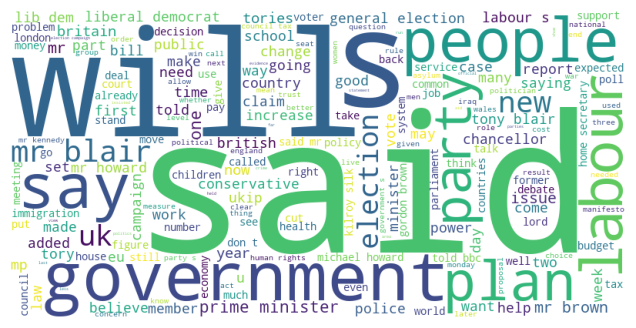

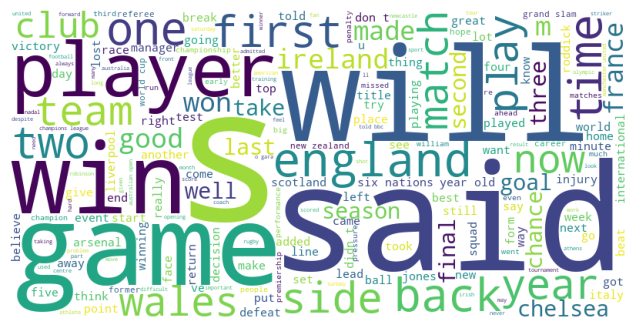

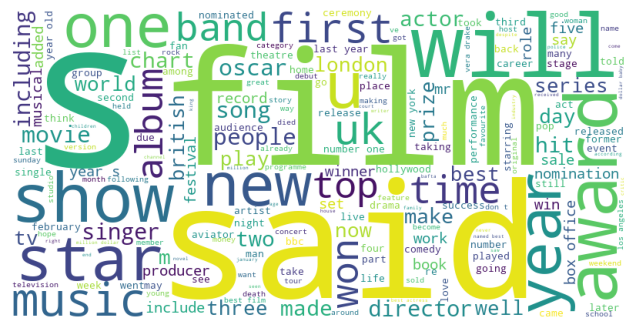

In [9]:
for category in category_names:
    text=" ".join(df[df["Category"]==category]['Text'].values)
    wc = WordCloud(width=800,height=400,background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.pipeline import make_pipeline              
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model=make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB())
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report, accuracy_score
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298

0.9563758389261745


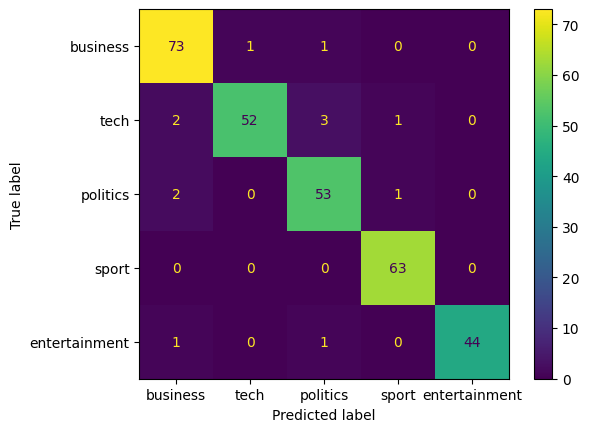

In [14]:
from sklearn.metrics import  confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=category_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=category_names)
disp.plot()

In [34]:
texts=["Swaroop sucided yesterday as Portugal failed to qualify for the world cup"]
prediction=model.predict(texts)
print(prediction)

['sport']


In [35]:
import joblib
print("Success")

Success


#Experiment with TF-IDF parameters such as max_features, ngram_range, and min_df.

In [41]:
settings = [
    {"max_features": 1000, "ngram_range": (1,1), "min_df": 1},
    {"max_features": 3000, "ngram_range": (1,2), "min_df": 2},
    {"max_features": 5000, "ngram_range": (1,3), "min_df": 5},
]
for s in settings:
    pipeline=make_pipeline(
        TfidfVectorizer(stop_words='english', max_features=s["max_features"], ngram_range=s["ngram_range"], min_df=s["min_df"]),
        MultinomialNB())
    pipeline.fit(X_train, y_train)
    y_pred=pipeline.predict(X_test)
    print(s,"Vocabulary Size:",len(pipeline.named_steps['tfidfvectorizer'].vocabulary_),
          "Accuracy:",accuracy_score(y_test, y_pred)),
   

{'max_features': 1000, 'ngram_range': (1, 1), 'min_df': 1} Vocabulary Size: 1000 Accuracy: 0.9664429530201343
{'max_features': 3000, 'ngram_range': (1, 2), 'min_df': 2} Vocabulary Size: 3000 Accuracy: 0.9697986577181208
{'max_features': 5000, 'ngram_range': (1, 3), 'min_df': 5} Vocabulary Size: 5000 Accuracy: 0.9765100671140939


In [9]:
#Custom Model to use always
import time
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
best_pipeline = make_pipeline(
    TfidfVectorizer(
        stop_words='english',
        max_features=3000,
        ngram_range=(1,2),
        min_df=2
    ),
    MultinomialNB()
)

# Measure training time
start_train = time.time()

best_pipeline.fit(X_train, y_train)

end_train = time.time()
nb_training_time = end_train - start_train

# Measure prediction time
start_predict = time.time()

predictions = best_pipeline.predict(X_test)

end_predict = time.time()
nb_prediction_time = end_predict - start_predict

# Accuracy
nb_accuracy = accuracy_score(y_test, predictions)*100

# Print results
print(f"Accuracy       : {nb_accuracy:.4f}")
print(f"Training Time  : {nb_training_time:.6f} seconds")
print(f"Prediction Time: {nb_prediction_time:.6f} seconds")

Accuracy       : 96.9799
Training Time  : 0.962352 seconds
Prediction Time: 0.143313 seconds


#Classify at least five custom news articles and record the predicted categories.

In [45]:
custom_news = [
    "India defeated Australia in the cricket world cup final.",
    "The government announced a new tax policy for small businesses.",
    "A new Marvel movie broke all box office records this weekend.",
    "Scientists developed an AI system to detect cancer earlier.",
    "Tesla unveiled its latest electric vehicle with improved battery life.",
    "The stock market saw a significant drop due to global economic concerns.",
    "A new study shows the benefits of a plant-based diet for heart health.",
]

predictions = best_pipeline.predict(custom_news)

for news, category in zip(custom_news, predictions):
    print("News:", news)
    print("Predicted Category:", category)
    print("-" * 50)

News: India defeated Australia in the cricket world cup final.
Predicted Category: sport
--------------------------------------------------
News: The government announced a new tax policy for small businesses.
Predicted Category: business
--------------------------------------------------
News: A new Marvel movie broke all box office records this weekend.
Predicted Category: entertainment
--------------------------------------------------
News: Scientists developed an AI system to detect cancer earlier.
Predicted Category: tech
--------------------------------------------------
News: Tesla unveiled its latest electric vehicle with improved battery life.
Predicted Category: business
--------------------------------------------------
News: The stock market saw a significant drop due to global economic concerns.
Predicted Category: business
--------------------------------------------------
News: A new study shows the benefits of a plant-based diet for heart health.
Predicted Category: bu

#Save the trained model and reload it to perform predictions on new data

In [54]:
import joblib

joblib.dump(best_pipeline, "news_classifier.pkl")

['news_classifier.pkl']

In [47]:
new_news = [
    "India won the cricket world cup final.",
    "The new superhero movie earned record box office revenue."
]
loaded_pipeline = joblib.load("news_classifier.pkl")
predictions = loaded_pipeline.predict(new_news)

for news, pred in zip(new_news, predictions):
    print(news)
    print("Predicted Category:", pred)
    print("-" * 50)

India won the cricket world cup final.
Predicted Category: sport
--------------------------------------------------
The new superhero movie earned record box office revenue.
Predicted Category: entertainment
--------------------------------------------------


5. Experiment with Train-Test Split Ratio
6. Evaluate the model using different train-test splits:
70% – 30% 
80% – 20% 
90% – 10% 
Compare the resulting accuracies.


In [48]:
splits = [0.3, 0.2, 0.1]

for test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    new_pipeline = make_pipeline(
        TfidfVectorizer(
            stop_words='english',
            max_features=3000,
            ngram_range=(1,2),
            min_df=2
        ),
        MultinomialNB()
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"Train-Test Split: {int((1-test_size)*100)}-{int(test_size*100)}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("-"*40)

Train-Test Split: 70-30
Accuracy: 0.9686800894854586
----------------------------------------
Train-Test Split: 80-20
Accuracy: 0.9731543624161074
----------------------------------------
Train-Test Split: 90-10
Accuracy: 0.9865771812080537
----------------------------------------


#Perform 5-Fold Cross Validation and calculate Mean Accuracy and Standard Deviation .


In [50]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

In [53]:
print("Accuracy of each fold:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Standard Deviation:", np.std(scores))
print("""
======================================================================
Discussion
======================================================================
The model demonstrates stable performance across the five folds of
cross-validation. The accuracies range from 95.30% to 97.99%, showing
only small variations between folds.

The mean accuracy of 96.78% indicates consistently high classification
performance, while the low standard deviation of 0.96% suggests that
the model's accuracy does not fluctuate significantly with different
train-test partitions.

Therefore, the model is considered stable, reliable, and capable of
generalizing well to unseen data.
======================================================================
""")

Accuracy of each fold: [0.96644295 0.95302013 0.97651007 0.97986577 0.96308725]
Mean Accuracy: 0.9677852348993289
Standard Deviation: 0.009632684627119024

Discussion
The model demonstrates stable performance across the five folds of
cross-validation. The accuracies range from 95.30% to 97.99%, showing
only small variations between folds.

The mean accuracy of 96.78% indicates consistently high classification
performance, while the low standard deviation of 0.96% suggests that
the model's accuracy does not fluctuate significantly with different
train-test partitions.

Therefore, the model is considered stable, reliable, and capable of
generalizing well to unseen data.



#Logistic Regression


In [12]:
import time

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv('bbc_news_dataset.csv')
X = df["Text"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
lr_model = make_pipeline(
    TfidfVectorizer(stop_words="english"),
    LogisticRegression(max_iter=1000, random_state=42)
)

In [5]:
start_train = time.time()

lr_model.fit(X_train, y_train)

end_train = time.time()

lr_training_time = end_train - start_train
print(f"Training time: {lr_training_time:.4f} seconds")

Training time: 0.5585 seconds


In [6]:
start_predict = time.time()

y_pred = lr_model.predict(X_test)

end_predict = time.time()

lr_prediction_time = end_predict - start_predict
print(f"Prediction time: {lr_prediction_time:.4f} seconds")

Prediction time: 0.1098 seconds


In [31]:
lr_accuracy = accuracy_score(y_test, y_pred)*100
print(f"Accuracy: {lr_accuracy:.2f}%")

Accuracy: 96.64%


In [15]:
print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy       : {lr_accuracy:.4f}")
print(f"Training Time  : {lr_training_time:.6f} seconds")
print(f"Prediction Time: {lr_prediction_time:.6f} seconds")

Logistic Regression Results
---------------------------
Accuracy       : 0.9664
Training Time  : 0.558545 seconds
Prediction Time: 0.109843 seconds


In [28]:
import joblib
joblib.dump(lr_model, "lr_news_classifier.pkl")

['lr_news_classifier.pkl']

In [20]:
new_texts = [
    "Apple launched a new smartphone with advanced AI features.",
    "The Prime Minister announced a new education policy.",
    "The football team won the championship."
]

predictions = lr_model.predict(new_texts)

for text, pred in zip(new_texts, predictions):
    print(f"News: {text}")
    print(f"Predicted Category: {pred}\n")

News: Apple launched a new smartphone with advanced AI features.
Predicted Category: tech

News: The Prime Minister announced a new education policy.
Predicted Category: politics

News: The football team won the championship.
Predicted Category: sport



#Support Vector Machine (SVM)

In [20]:
import time
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
df=pd.read_csv('bbc_news_dataset.csv')
X = df["Text"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
svm_model = make_pipeline(
    TfidfVectorizer(stop_words="english"),
    LinearSVC(C=1.0, random_state=42)
)

In [23]:
start_train = time.time()

svm_model.fit(X_train, y_train)

end_train = time.time()

svm_training_time = end_train - start_train
print(f"SVM Training time: {svm_training_time:.4f} seconds")

SVM Training time: 0.3067 seconds


In [24]:
start_predict = time.time()

svm_predictions = svm_model.predict(X_test)

end_predict = time.time()

svm_prediction_time = end_predict - start_predict
print(f"SVM Prediction time: {svm_prediction_time:.4f} seconds")

SVM Prediction time: 0.0707 seconds


In [25]:
svm_accuracy = accuracy_score(y_test, svm_predictions)*100
print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 97.9866


In [26]:
print("===== Linear SVM =====")
print(f"Accuracy        : {svm_accuracy:.4f}")
print(f"Training Time   : {svm_training_time:.6f} seconds")
print(f"Prediction Time : {svm_prediction_time:.6f} seconds")

===== Linear SVM =====
Accuracy        : 97.9866
Training Time   : 0.306666 seconds
Prediction Time : 0.070686 seconds


In [27]:
import joblib
joblib.dump(svm_model, "svm_news_classifier.pkl")

['svm_news_classifier.pkl']

#Test on New Data

In [16]:
new_news = [
    "The Prime Minister announced a new economic policy to improve employment opportunities.",
    "Manchester United secured a thrilling victory in the Champions League final.",
    "Apple unveiled its latest AI-powered iPhone with advanced camera features.",
    "Scientists have discovered a new planet that may support life.",
    "The stock market reached a record high after strong company earnings."
]

predictions = svm_model.predict(new_news)

for news, category in zip(new_news, predictions):
    print("News:", news)
    print("Predicted Category:", category)
    print("-" * 70)

News: The Prime Minister announced a new economic policy to improve employment opportunities.
Predicted Category: business
----------------------------------------------------------------------
News: Manchester United secured a thrilling victory in the Champions League final.
Predicted Category: sport
----------------------------------------------------------------------
News: Apple unveiled its latest AI-powered iPhone with advanced camera features.
Predicted Category: tech
----------------------------------------------------------------------
News: Scientists have discovered a new planet that may support life.
Predicted Category: entertainment
----------------------------------------------------------------------
News: The stock market reached a record high after strong company earnings.
Predicted Category: business
----------------------------------------------------------------------


#Comparision Table

In [32]:
import pandas as pd

comparison = pd.DataFrame({
    "Algorithm": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        round(nb_accuracy, 4),
        round(lr_accuracy, 4),
        round(svm_accuracy, 4)
    ],
    "Training Time (s)": [
        round(nb_training_time, 6),
        round(lr_training_time, 6),
        round(svm_training_time, 6)
    ],
    "Prediction Time (s)": [
        round(nb_prediction_time, 6),
        round(lr_prediction_time, 6),
        round(svm_prediction_time, 6)
    ]
})

print(comparison)

                 Algorithm  Accuracy  Training Time (s)  Prediction Time (s)
0  Multinomial Naive Bayes   96.9799           0.962352             0.143313
1      Logistic Regression   96.6443           0.558545             0.109843
2               Linear SVM   97.9866           0.306666             0.070686
